In [7]:
#--------------------------- 
#  環境設定
#--------------------------- 
import os
import pandas as pd
import matplotlib.pyplot as plt
#from itables import options
# import ipywidgets as widgets
import matplotlib.font_manager as fm   # ★これを追加
from IPython.display import display
# import dtale

# 作業ディレクトリを切り替える
os.chdir('/Users/imaihiroshi/Documents/WORK/Programing/Python/narative_experiment')

# 日本語フォント設定（Mac の場合は "Hiragino Sans" が一般的）
font_path = "/System/Library/Fonts/ヒラギノ角ゴシック W3.ttc"
jp_font = fm.FontProperties(fname=font_path)
plt.rcParams['font.family'] = jp_font.get_name()

plt.rcParams['pdf.fonttype'] = 42   # TrueType
plt.rcParams['ps.fonttype'] = 42
#plt.rcParams['font.family'] = 'DejaVu Sans'
#plt.rcParams['font.family'] = 'Hiragino Sans'

# Matplotlib の描画スタイルを「ggplot風」に切り替える
plt.style.use("ggplot")

# ワーニングを強制的に消す
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

#--------------------------- 
#  定数と関数定義
#--------------------------- 

# カンマや通貨記号を除去して int に変換する関数
def clean_numeric(series):
    return (
        series.astype(str)
        .str.replace(r'[,\s¥￥円]', '', regex=True)
        .astype(int)
    )

def plot_histogram(df, column_name):
    plt.hist(df[column_name], bins=30, color='blue', edgecolor='black')
    plt.title(f'Histogram of {column_name}')
    plt.xlabel(column_name)
    plt.ylabel('Frequency')
    plt.grid(True)
    plt.show()

#------------------------------------- 
#  ファイルの読み込みとデータフレームへの格納
#------------------------------------- 
#CSV_FILE = './data/csv/Data_20250925.csv'
CSV_FILE = './data/csv/Data_20251007.csv'
df = pd.read_csv(CSV_FILE)
df_original = df

#--------------------------- 
#  上代データの数値変換
#--------------------------- 
df["上代数値"] = clean_numeric(df["上代"])
df


,品番,img_file_Name,名前,ブランド名,チャネル,上代,年度,会期月,シーズン,ステップ,ワイヤー,タイプ,シーン1,シーン2,補整力,シルエット,着用感,上代数値
0,CA115101,CA115101.jpg,ジャスミン,NY,店舗,"8,900",定番,NaN,通年,1,あり,一般,見せない,日中,5,自然,強,8900
1,BT125101,BT125101.jpg,ﾌﾞﾗﾃﾞﾘｽ ｽﾑｰｽﾞﾓｰﾙﾄﾞｶｯﾌﾟﾌﾞﾗ25S1,FIT,店舗・EC,"10,000",25SS,2025年3月,夏,なし,あり,一般,見せない,日中,4,自然,中,10000
2,BT125103,BT125103.jpg,ﾌﾞﾗﾃﾞﾘｽ ﾇｰﾃﾞｨﾓｰﾙﾄﾞｶｯﾌﾟﾌﾞﾗ25S1,FIT,店舗・EC,"10,000",25SS,2025年3月,夏,なし,あり,一般,見せない,日中,4,自然,弱,10000
3,BT09501,BT09501.jpg,パテッドブラ,FIT,店舗・EC,"6,000",26SS,2026年3月,夏,なし,なし,一般,見せる,日中,2,自然,中,6000
4,BT09503,BT09503.jpg,チュールブラキャミ,FIT,店舗・EC,"7,500",26SS,2026年3月,夏,なし,なし,一般,見せる,日中,2,自然,中,7500
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
146,MG525403,MG525403.jpg,ベロアタッチリブブラタンクトップ,MAGIC,EC,"5,800",定番,2025年12月予定,冬,0,なし,一般,見せる,日中,2,自然,弱,5800
147,MG525404,MG525404.jpg,ベロアタッチリブブラワンピース,MAGIC,EC,"7,000",定番,2025年12月予定,冬,0,なし,一般,見せる,日中,2,自然,弱,7000
148,MG07502,MG07502.jpg,ひんやりブラキャミ,MAGIC,EC,"5,400",定番,2026年4月\n予定,夏,0,なし,一般,見せる,日中,2,自然,弱,5400
149,MG02503,MG02503.jpg,リブブラタンクトップ,MAGIC,EC,"5,400",定番,2026年2月\n予定,夏,0,なし,一般,見せる,日中,2,自然,弱,5400


In [8]:
# ==============================================================================
# 変数選択の設定パネル
# ==============================================================================
# dfに存在する全ての変数名が、デフォルト値「1 (使う)」で自動的に設定されます。
# 分析に使わない変数の値だけを「0」に書き換えてください。

variable_selector = {
    '品番': 1,
     'img_file_Name': 0,
     '名前': 0,
     'ブランド名': 1,
     'チャネル': 1,
     '上代': 0,
     '年度': 0,
     '会期月': 0,
     'シーズン': 1,
     'ステップ': 1,
     'ワイヤー': 1,
     'タイプ': 1,
     'シーン1': 1,
     'シーン2': 1,
     '補整力': 1,
     'シルエット': 1,
     '着用感': 0,
     '上代数値': 1,
}


# ---------------------------------------------------------
# dfを更新する処理 (この部分は変更不要です)
# variable_selectorで値が1になっている変数名だけをリストとして抽出
selected_columns = [column for column, keep in variable_selector.items() if keep == 1]

# 元のdfから、選択された変数の列だけを取り出して、dfを上書きする
df = df[selected_columns]

print("✔ 更新完了！")
df

✔ 更新完了！


,品番,ブランド名,チャネル,シーズン,ステップ,ワイヤー,タイプ,シーン1,シーン2,補整力,シルエット,上代数値
0,CA115101,NY,店舗,通年,1,あり,一般,見せない,日中,5,自然,8900
1,BT125101,FIT,店舗・EC,夏,なし,あり,一般,見せない,日中,4,自然,10000
2,BT125103,FIT,店舗・EC,夏,なし,あり,一般,見せない,日中,4,自然,10000
3,BT09501,FIT,店舗・EC,夏,なし,なし,一般,見せる,日中,2,自然,6000
4,BT09503,FIT,店舗・EC,夏,なし,なし,一般,見せる,日中,2,自然,7500
...,...,...,...,...,...,...,...,...,...,...,...,...
146,MG525403,MAGIC,EC,冬,0,なし,一般,見せる,日中,2,自然,5800
147,MG525404,MAGIC,EC,冬,0,なし,一般,見せる,日中,2,自然,7000
148,MG07502,MAGIC,EC,夏,0,なし,一般,見せる,日中,2,自然,5400
149,MG02503,MAGIC,EC,夏,0,なし,一般,見せる,日中,2,自然,5400


質的データ（変換対象）: ['ブランド名', 'チャネル', 'シーズン', 'ステップ', 'ワイヤー', 'タイプ', 'シーン1', 'シーン2', 'シルエット']
量的データ（正規化対象）: ['補整力', '上代数値']
X軸を反転しました。
Y軸を反転しました。


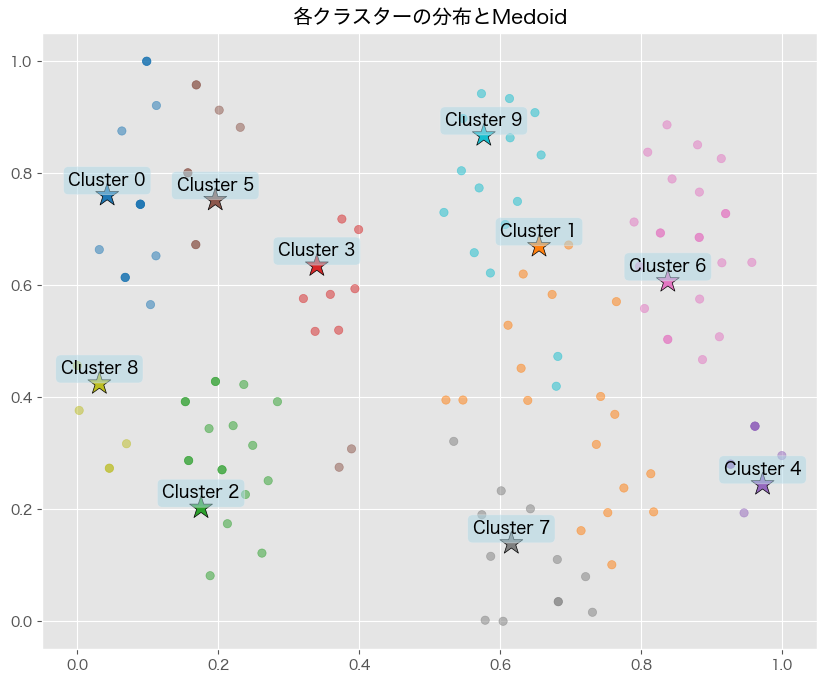


処理完了！ df_medoid の先頭:


cluster
0    19
1    20
2    19
3     8
4    10
5    14
6    24
7    14
8     7
9    16
Name: count, dtype: int64

In [9]:
# ==============================================================================
# スペクトルクラスタリング + medoid抽出 + t-SNE埋め込み
# ==============================================================================
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.cluster import SpectralClustering
from sklearn.metrics import pairwise_distances
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import japanize_matplotlib # 日本語化のために追加
from sklearn.preprocessing import MinMaxScaler


# ★★★★★★★★★★★★★★★★★
df_cls = df.iloc[:, 1:13]
# ★★★★★★★★★★★★★★★★★

# --- 2. データ型の特定 ---
categorical_features = df_cls.select_dtypes(include=['object', 'category']).columns
numerical_features = df_cls.select_dtypes(include=np.number).columns

print("質的データ（変換対象）:", categorical_features.tolist())
print("量的データ（正規化対象）:", numerical_features.tolist())

# --- 3. 前処理パイプラインの作成 ---
numerical_transformer = StandardScaler()
categorical_transformer = OneHotEncoder(handle_unknown='ignore')

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_features),
        ('cat', categorical_transformer, categorical_features)
    ],
    remainder='passthrough'
)

# --- 4. スペクトルクラスタリング + medoid計算関数 ---
# ▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼ 修正部分1: 引数を追加 ▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼
def perform_spectral_clustering_with_medoids(dataframe, n_clusters, flip_x=False, flip_y=False):
# ▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲
    """
    スペクトルクラスタリングを実行し、クラスタごとにmedoidを計算。
    各サンプルのmedoid距離スコアを求め、t-SNEで2次元座標を作成する。
    
    Args:
        dataframe (pd.DataFrame): 分析対象のデータフレーム
        n_clusters (int): クラスター数
        flip_x (bool): Trueの場合、X軸を反転させる
        flip_y (bool): Trueの場合、Y軸を反転させる
    
    Returns:
        df_medoid: クラスタ・スコア・座標を追加したデータフレーム
    """
    # 1. 前処理データを作成
    X_processed = preprocessor.fit_transform(dataframe)
    
    # 2. スペクトルクラスタリング
    clusterer = SpectralClustering(
        n_clusters=n_clusters,
        affinity='nearest_neighbors',
        random_state=42,
        n_neighbors=10
    )
    labels = clusterer.fit_predict(X_processed)
    
    # 3. medoid計算とスコア付与
    medoid_indices = []
    scores = np.zeros(len(X_processed))
    
    for k in range(n_clusters):
        members_idx = np.where(labels == k)[0]
        if len(members_idx) == 0:
            continue
        
        members = X_processed[members_idx]
        dist_matrix = pairwise_distances(members)
        medoid_local_idx = np.argmin(dist_matrix.sum(axis=1))
        medoid_idx = members_idx[medoid_local_idx]
        medoid_indices.append(medoid_idx)
        scores[members_idx] = dist_matrix[medoid_local_idx]
    
    # 4. t-SNE埋め込み
    tsne = TSNE(n_components=2, random_state=42, perplexity=30)
    X_embedded = tsne.fit_transform(X_processed)
    
    # 座標を0-1の範囲にスケーリング
    scaler = MinMaxScaler()
    X_embedded = scaler.fit_transform(X_embedded)
    
    # ▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼ 修正部分2: 軸の反転処理 ▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼
    # flip_xがTrueならX軸（0列目）を反転 (1 - 元の座標)
    if flip_x:
        X_embedded[:, 0] = 1 - X_embedded[:, 0]
        print("X軸を反転しました。")

    # flip_yがTrueならY軸（1列目）を反転 (1 - 元の座標)
    if flip_y:
        X_embedded[:, 1] = 1 - X_embedded[:, 1]
        print("Y軸を反転しました。")
    # ▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲

    # medoid座標 (スケーリング・反転後の座標から取得)
    medoid_coords = X_embedded[medoid_indices]
    
    # 5. 可視化
    plt.figure(figsize=(10, 8))
    plt.scatter(X_embedded[:,0], X_embedded[:,1], c=labels, cmap="tab10", alpha=0.5)
    plt.scatter(medoid_coords[:,0], medoid_coords[:,1],
                c=range(len(medoid_coords)), cmap="tab10",
                marker="*", s=300, edgecolor="black")
    plt.title("各クラスターの分布とMedoid")

    for i, (x, y) in enumerate(medoid_coords):
        plt.text(x, y + 0.01, f'Cluster {i}', fontsize=12,
                 ha='center', va='bottom', color='black',
                 bbox=dict(boxstyle='round,pad=0.3', fc='lightblue', alpha=0.5))

    plt.savefig("./fig/ClusterPlot.pdf")
    plt.show()
    
    # 6. 新しいデータフレームを作成
    df_medoid = dataframe.copy()
    df_medoid["cluster"] = labels
    df_medoid["medoid_score"] = scores
    df_medoid["tsne_x"] = X_embedded[:,0]
    df_medoid["tsne_y"] = X_embedded[:,1]
    
    return df_medoid

# --- 5. 実行 ---
# ★★★★★★★★★★★★★★★★★
# クラスター数の設定
num_of_clusters = 10
# ★★★★★★★★★★★★★★★★★

# ▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼ 修正部分3: 関数の呼び出し方 ▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼
# 例：Y軸だけを反転させたい場合
df_medoid = perform_spectral_clustering_with_medoids(df_cls, n_clusters=num_of_clusters, flip_x=True, flip_y=True)
# ▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲

print("\n処理完了！ df_medoid の先頭:")
df_medoid['cluster'].value_counts().sort_index()

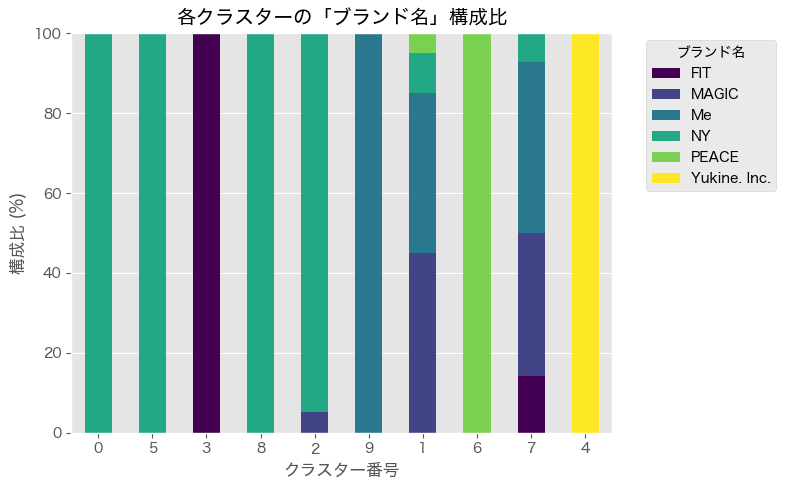

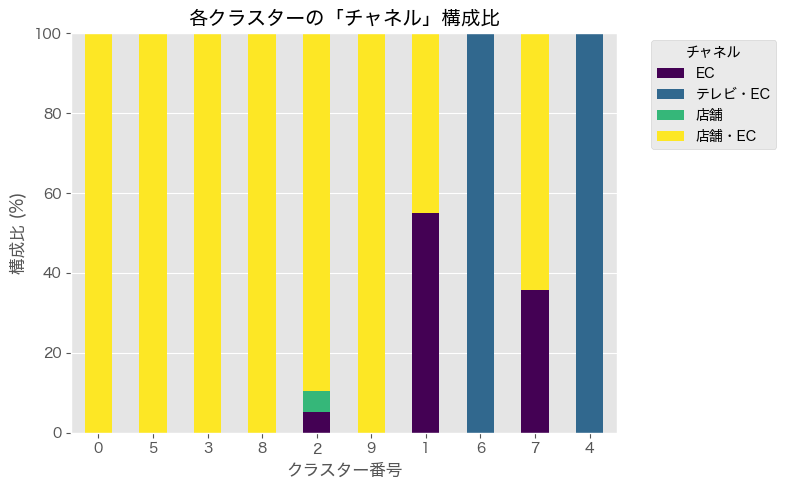

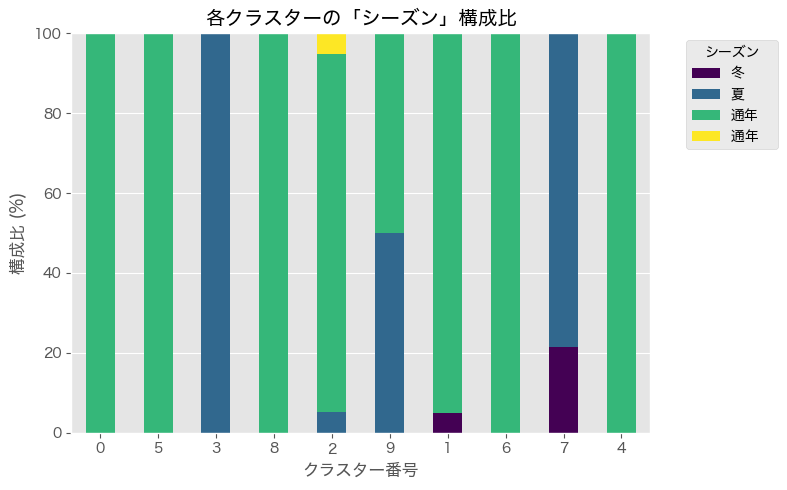

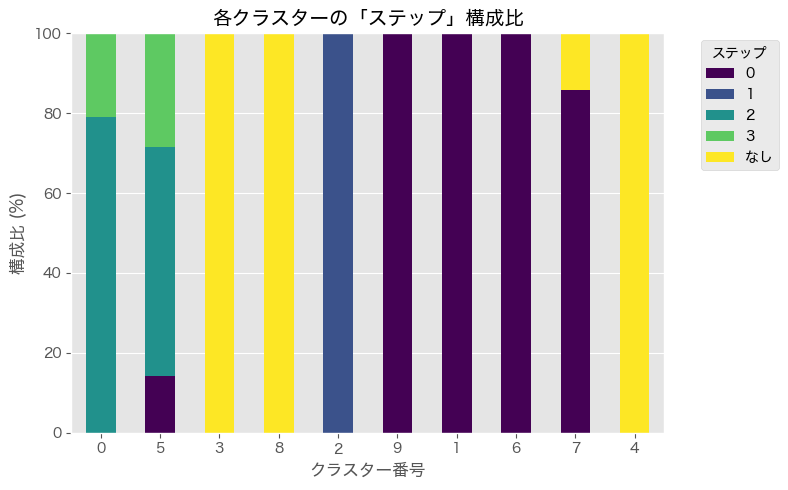

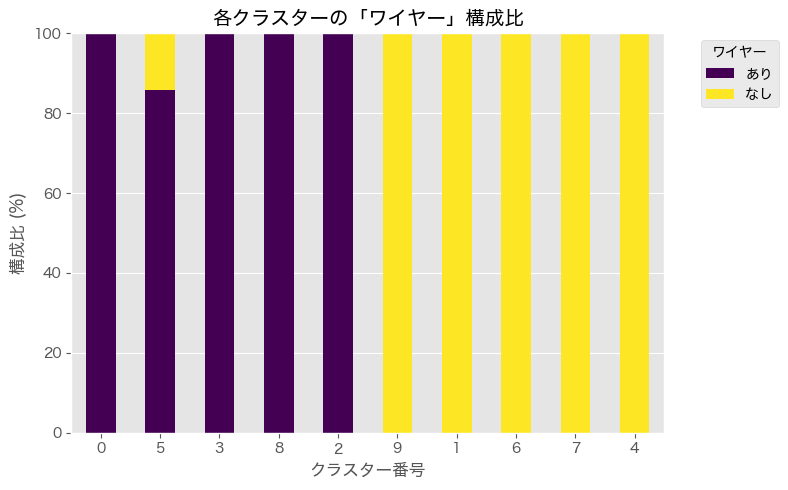

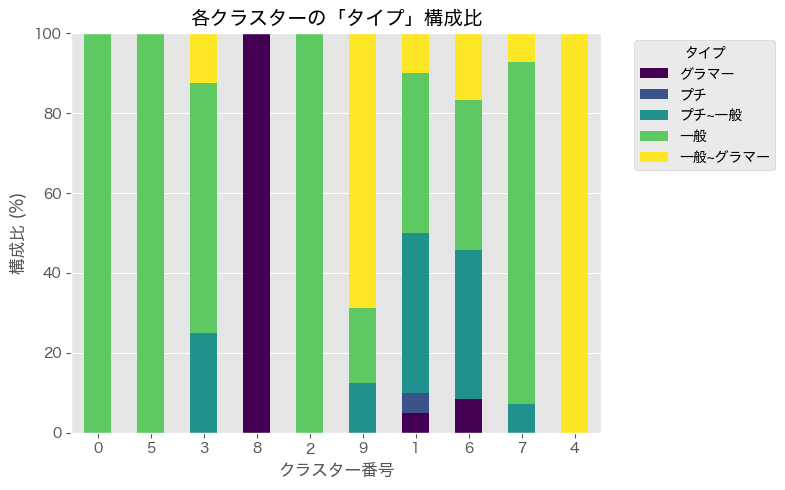

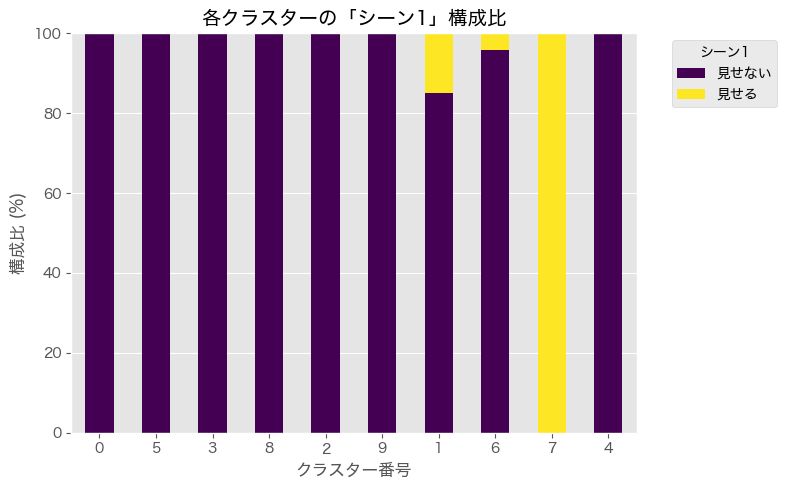

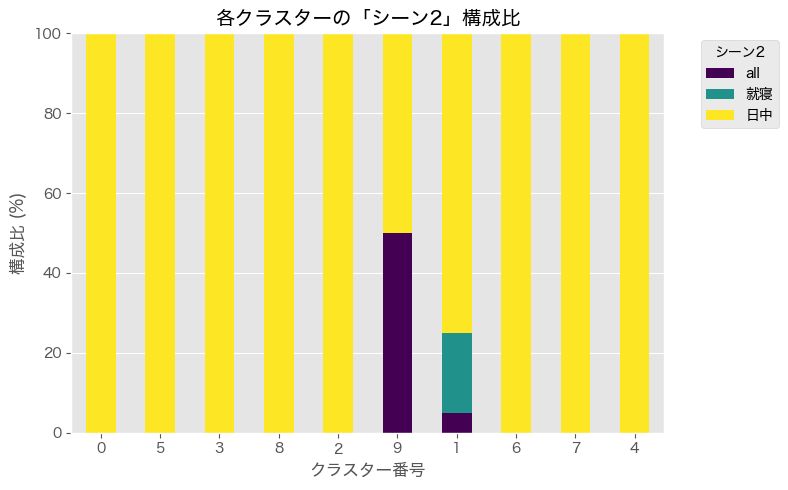

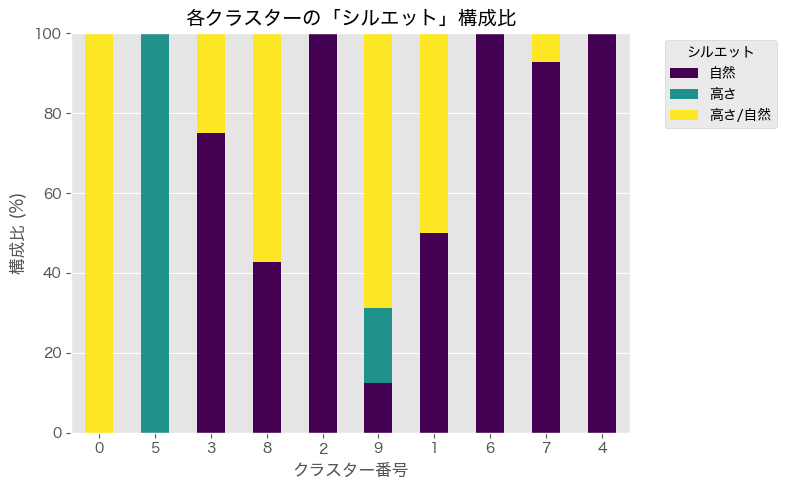


--- 量的変数のグラフ ---


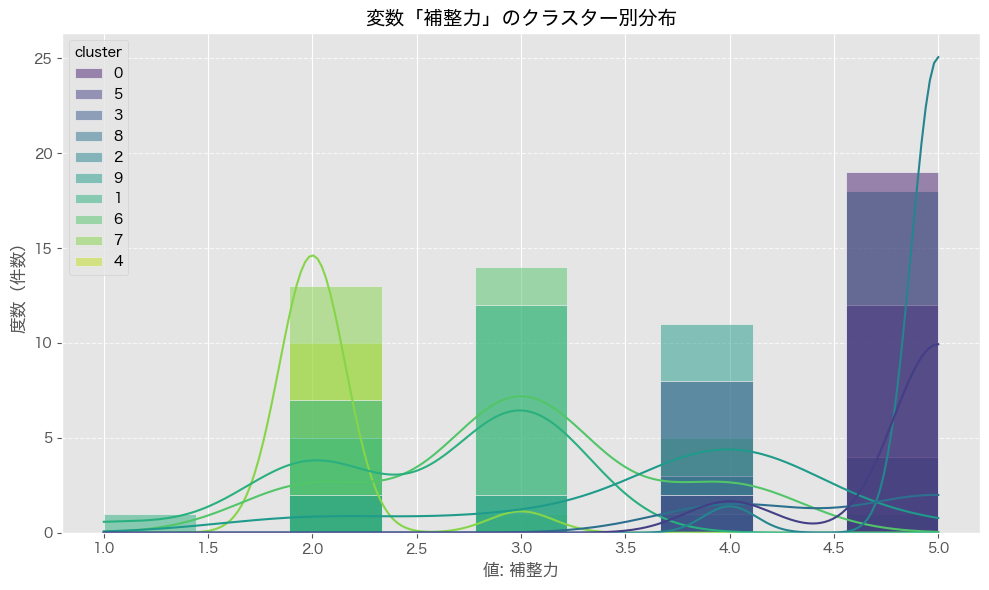

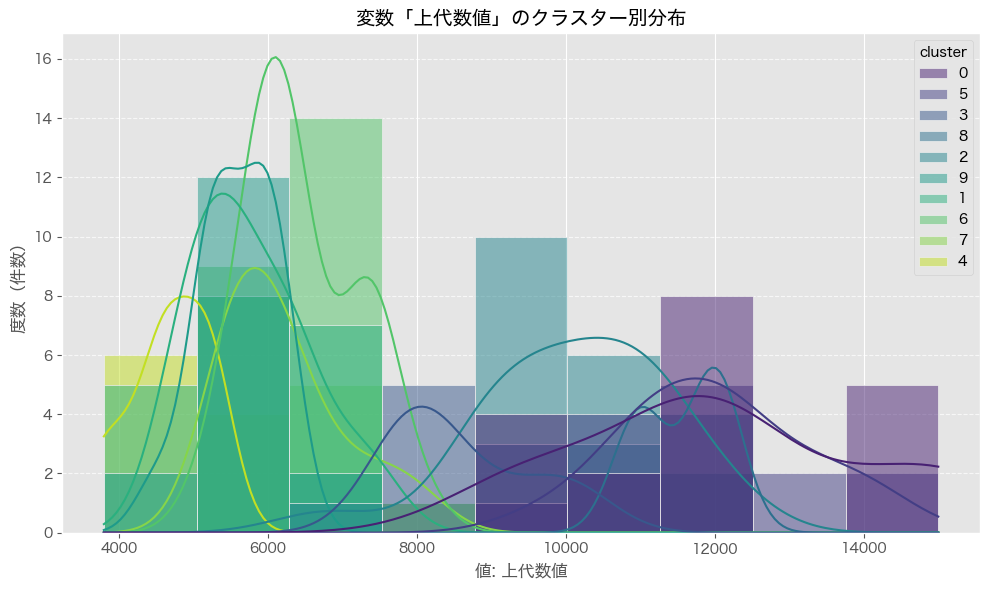

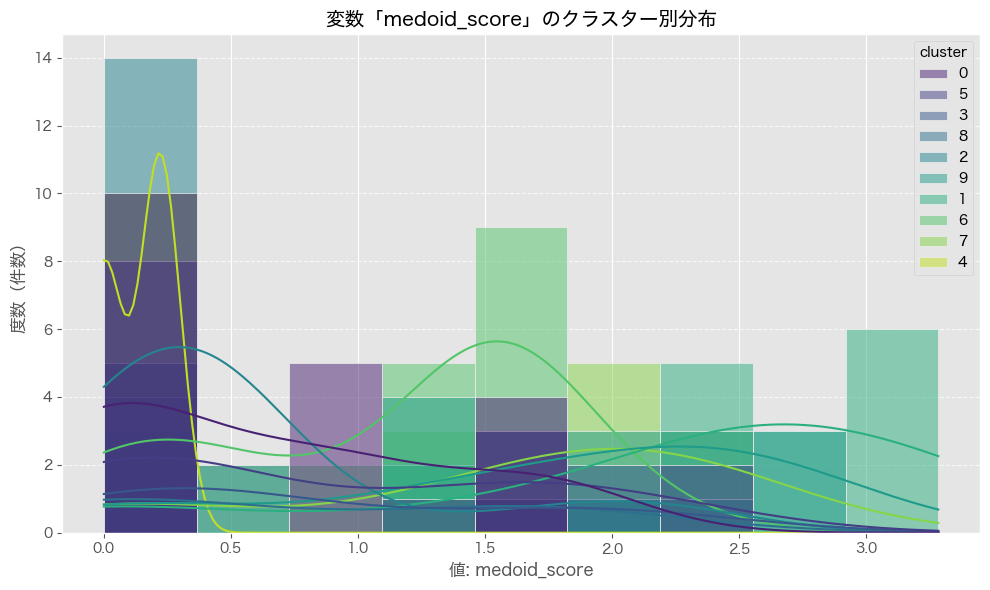

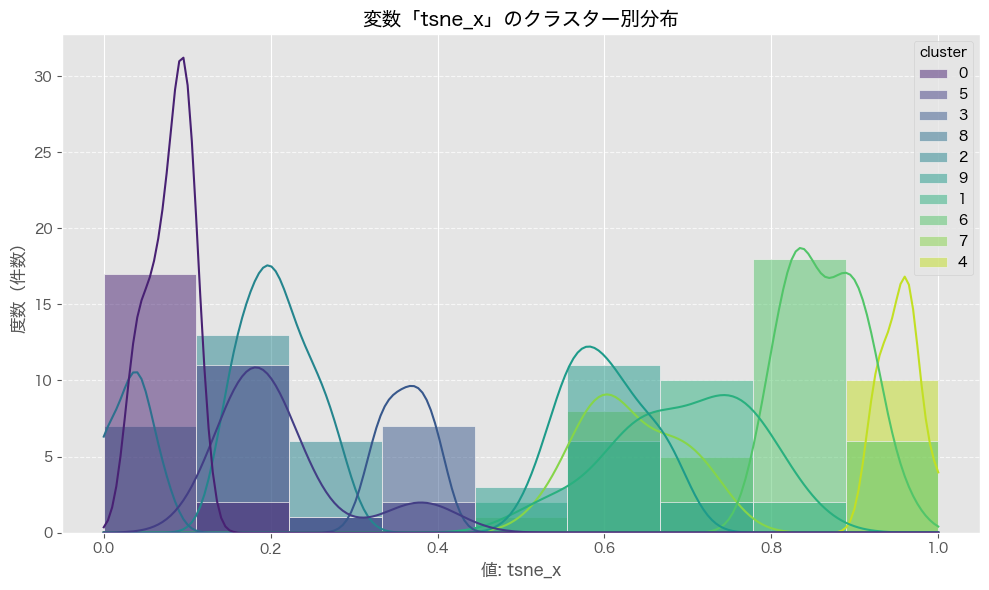

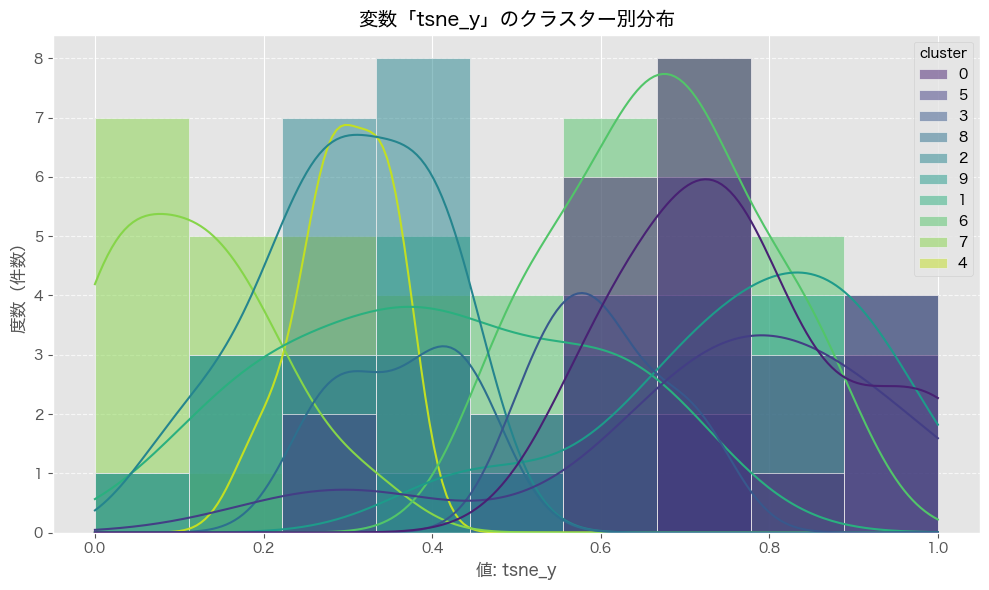

In [10]:
# ==============================================================================
# クラスター特徴把握　　その2　　積み上げ棒グラフ
# ==============================================================================
import seaborn as sns
import matplotlib.font_manager as fm


# 日本語フォントの設定（ご自身の環境に合わせてコメントを外してパスを指定してください）
font_path = '/System/Library/Fonts/ヒラギノ角ゴシック W3.ttc'

# --------------------------------------------------
# メインの処理：全ての質的変数についてグラフを描画
# --------------------------------------------------
# 'cluster'列を除いた質的変数（object型またはcategory型）の列名リストを取得
categorical_cols = df_medoid.select_dtypes(include=['object', 'category']).columns

# ★★★★★★★★★★★★★★★★★
# 任意の順番を指定
cluster_order = [0,5,3,8,2,9,1,6,7,4]
#cluster_order = [9,2,4,11,18,3,1,5,8,10,17,19,14,6,12,16,15,13,7,0]
# ★★★★★★★★★★★★★★★★★

if len(categorical_cols) == 0:
    print("データフレームに質的変数が見つかりませんでした。")
else:
    # 各質的変数についてループ処理
    for col in categorical_cols:
        # クラスターごとの構成比（列方向の合計が100%になるように）を計算
        cross_table_norm = pd.crosstab(df_medoid[col], df_medoid['cluster'], normalize='columns') * 100

        # クロス集計の列を並べ替える
        cross_table_norm = cross_table_norm[cluster_order]
            
        # 積み上げ棒グラフを描画
        ax = cross_table_norm.T.plot(
            kind='bar',
            stacked=True,
            figsize=(8, 5),
            colormap='viridis' # グラフの色合いを変更
        )

        # グラフの体裁を整える
        plt.title(f'各クラスターの「{col}」構成比', fontsize=14)
        plt.ylabel('構成比 (%)', fontsize=12)
        plt.xlabel('クラスター番号', fontsize=12)
        plt.xticks(rotation=0) # X軸のラベル（クラスター番号）を水平に表示
        plt.legend(title=col, bbox_to_anchor=(1.05, 1), loc='upper left') # 凡例をグラフの外側に配置
        
        # Y軸の範囲を0%から100%に固定
        plt.ylim(0, 100)
        
        # グラフの周囲の余白を自動調整
        plt.tight_layout()

        #グラフを保存
        plt.savefig(f"./fig/Plot_{col}.png")
        
        # グラフを表示
        plt.show()

# ==============================================================================
# 【追加部分】量的変数のヒストグラム（クラスター別）
# ==============================================================================
print("\n--- 量的変数のグラフ ---")
quantitative_cols = df_medoid.select_dtypes(include=['number', 'float', 'int']).columns.drop('cluster')

if len(quantitative_cols) == 0:
    print("データフレームに量的変数が見つかりませんでした。")
else:
    for col in quantitative_cols:
        plt.figure(figsize=(10, 6))

        df_medoid["cluster"] = pd.Categorical(df_medoid["cluster"], categories=cluster_order, ordered=True)
        
        sns.histplot(
            data=df_medoid,
            x=col,
            hue='cluster',
            hue_order=cluster_order,   # ★ 順序を指定
            palette='viridis',
            kde=True,
            multiple="layer"
        )

        plt.title(f'変数「{col}」のクラスター別分布', fontsize=14)
        plt.xlabel(f'値: {col}', fontsize=12)
        plt.ylabel('度数（件数）', fontsize=12)
        plt.grid(axis='y', linestyle='--', alpha=0.7)
        plt.tight_layout()

        plt.savefig(f"./fig/Plot_Numeric{col}.png")
        plt.show()

In [17]:
# ==============================================================================
# 　JSONファイルの書き出し
# ==============================================================================
import pandas as pd
import json

#品番名を最初の列として加える
col1=df_original.iloc[:,[0]]
df_result = pd.concat([col1,df_medoid],axis=1)

def export_medoid_json(df_result, output_path="./data/df_medoid.json"):
    nodes = []

    # ★★★★★★★★★★★★★★★★★
    #代表を幾つまで書き出すか
    cls_rep = 5
    # ★★★★★★★★★★★★★★★★★
    
    # 各クラスタごとに medoid_score が小さい順に2件のインデックスを取得
    medoid_indices = (
        df_result.groupby("cluster", observed=False)["medoid_score"]
        .apply(lambda x: x.nsmallest(cls_rep).index)
        .explode()
        .values
    )

    for idx, row in df_result.iterrows():
        node = {
            "id": str(row["品番"]),
            "icon": f"images/{row['品番']}.jpg",
            "x": float(2000 * row["tsne_x"] ),
            "y": float(1480 * -row["tsne_y"] ),
           # "x": row["tsne_x"] ,
           # "y": row["tsne_y"] ,
            "Rep": 1 if idx in medoid_indices else 0,   # 代表なら1
            "cluster": int(row["cluster"])
        }
        nodes.append(node)

    data = {
        "nodes": nodes,
        "links": []  # 今回はリンクなし
    }

    with open(output_path, "w", encoding="utf-8") as f:
        json.dump(data, f, ensure_ascii=False, indent=2)

    print(f"全データ {len(nodes)} 件を書き出しました。代表点は {len(medoid_indices)} 件です。")

# ★★★★★★★★★★★★★★★★★
# 実行例
export_medoid_json(df_result, "./data/Data_20251013.json")
# ★★★★★★★★★★★★★★★★★

全データ 151 件を書き出しました。代表点は 50 件です。
